<a href="https://colab.research.google.com/github/divyansshu/pytorch/blob/main/neural_network_classification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [ ]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f'First 5 samples of X: \n {X[:5]}')
print(f'First 5 samples of y: \n {y[:5]}')

First 5 samples of X: 
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: 
 [1 1 1 1 0]


In [ ]:
circles = pd.DataFrame(
    {
        'X1': X[:, 0],
        'X2': X[:, 1],
        'label': y
    }
)

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


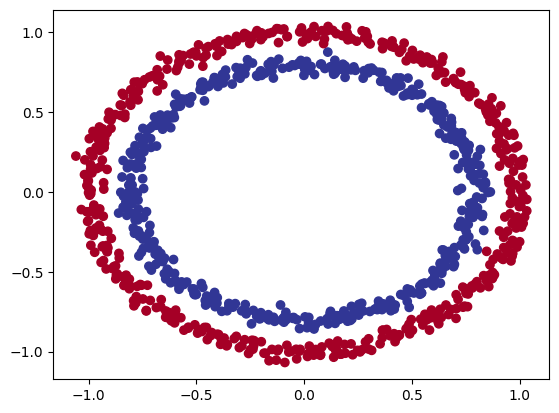

In [ ]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

numpys has default datatype of float64 but pytorch has default data type of float32. So conversion of data type is also necessary.

In [ ]:
# turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [ ]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [ ]:
y_train.shape, y_test.shape

(torch.Size([800]), torch.Size([200]))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()


  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


In [ ]:
model_1 = CircleModel()
model_1

CircleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.1415, -0.6193],
                      [ 0.2681,  0.6018],
                      [-0.1597,  0.0183],
                      [ 0.6087,  0.3075],
                      [-0.0594, -0.4769],
                      [-0.1816,  0.5349],
                      [-0.3143, -0.2715],
                      [-0.6505, -0.4317],
                      [ 0.1160,  0.6378],
                      [ 0.3428,  0.6045]])),
             ('layer_1.bias',
              tensor([ 0.2955, -0.3858, -0.1783,  0.3028,  0.6015, -0.0401, -0.1287, -0.3786,
                       0.6630, -0.6073])),
             ('layer_2.weight',
              tensor([[-0.2208, -0.1224, -0.0310, -0.1490,  0.1478, -0.1015, -0.0937, -0.0605,
                       -0.2129, -0.0074],
                      [ 0.1291,  0.3022,  0.0861, -0.0970, -0.0895,  0.2532, -0.2435,  0.2160,
                       -0.0187, -0.1311],
                      [-0.1938,  0.2764,  0.1027,  0.0458, -0.2433, -0.2

In [ ]:
# set up loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

In [ ]:
# calculate accuracy
def accuracy(y_true, y_pred):
  correct = torch.eq(y_pred, y_true).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

#  Training Loop
* forward pass
* loss calculate
* optimizer zero grad(reset previous gradients)
* loss backward(backpropogation)
* optimizer step (parameters are updated)

In [ ]:
y_logits = model_1(X_train)
y_logits.shape

torch.Size([800, 1])

In [ ]:
epochs = 500

for epoch in range(epochs):

  model_1.train()

  # 1. forward pass
  y_logits = model_1(X_train)
  y_preds = torch.round(torch.sigmoid(y_logits.squeeze_()))

  # 2. calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy(y_train, y_preds)

  # 3. reset previous gradients
  optimizer.zero_grad()

  # 4. backward propogation
  loss.backward()

  # 5. update gradients
  optimizer.step()

  # testing loop
  model_1.eval()
  with torch.inference_mode():

    # forward pass
    test_logits = model_1(X_test)
    test_preds = torch.round(torch.sigmoid(test_logits.squeeze_()))

    # calculate loss
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy(y_test, test_preds)

    print(f'Epoch: {epoch} | Train loss: {loss:.2f}% | Train acc: {acc:.2f}% | Test loss: {test_loss:.2f}% | Test Acc: {test_acc:.2f}%')


Epoch: 0 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 1 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 2 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 3 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 4 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 5 | Train loss: 0.71% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 6 | Train loss: 0.70% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 7 | Train loss: 0.70% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 8 | Train loss: 0.70% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 9 | Train loss: 0.70% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 10 | Train loss: 0.70% | Train acc: 50.00% | Test loss: 0.70% | Test Acc: 50.00%
Epoch: 11 | Train loss: 0.70% | Train acc:

In [ ]:
import requests
from pathlib import Path
if Path('helper_functions.py').is_file():
  print('helper_functions.py already exists, skipping download')
else:
  print('Downloading helper_functions.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

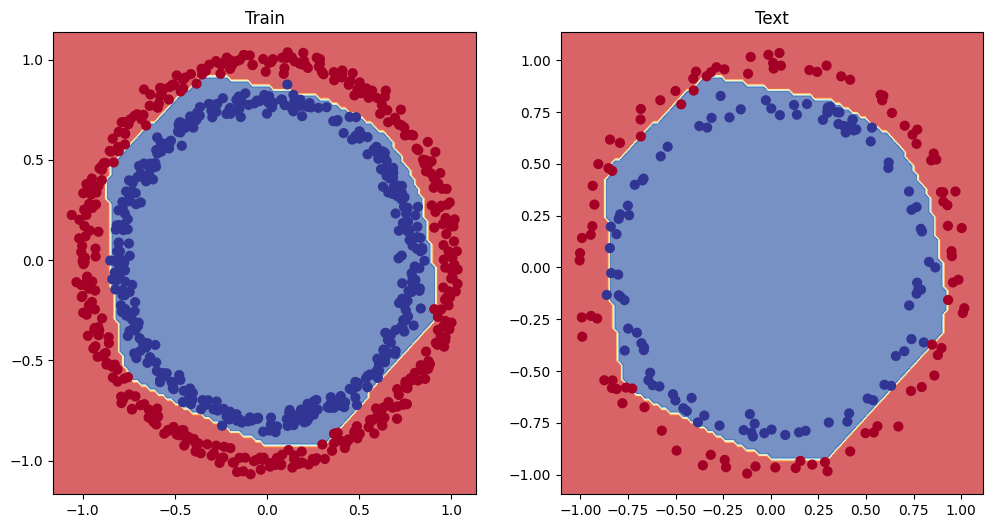

In [ ]:
# plot decision boundaries for training and testing sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1,2,2)
plt.title('Text')
plot_decision_boundary(model_1, X_test, y_test)

# Replicating the ReLU activation function to understand its working

In [ ]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

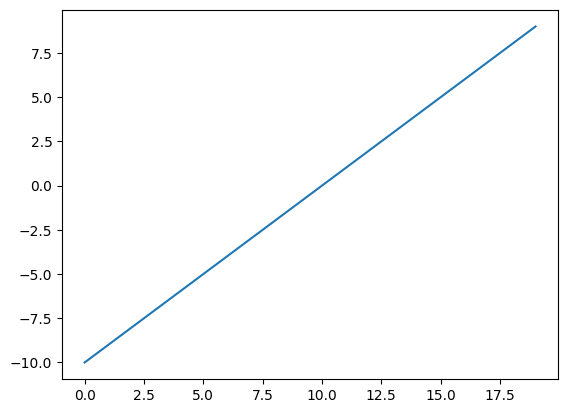

In [ ]:
plt.plot(A)

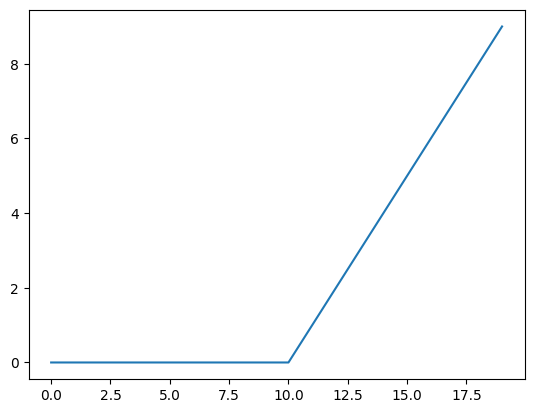

In [ ]:
plt.plot(relu(A))

In [ ]:
def relu(x):
  return torch.maximum(torch.tensor(0), x)
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

# preparing data to see if our model can fit a straight line

In [ ]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01
X_regression = torch.arange(start, end, step).unsqueeze(dim=1) # 100 rows 1 cols
y_regression = weight * X_regression + bias

In [ ]:
X_regression[:5]

In [ ]:
y_regression[:5]

In [ ]:
train_split = int(len(X_regression) * 0.8)
X_train, y_train = X_regression[:train_split], y_regression[:train_split]
X_test, y_test = X_regression[train_split:], y_regression[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

In [ ]:
plot_predictions(X_train, y_train, X_test, y_test)

# adjusting the model_1 to to fit a straight lint

In [ ]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
)
model_2

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [ ]:
# training and testing loop
epochs = 1000
for epoch in range(epochs):
  model_2.train()
  y_preds = model_2(X_train)
  loss = loss_fn(y_preds, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_preds = model_2(X_test)
    test_loss = loss_fn(test_preds, y_test)

  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | train loss: {loss} | test loss: {test_loss}')

In [ ]:
model_2.eval()
with torch.inference_mode():
  preds = model_2(X_test)

plot_predictions(X_train, y_train, X_test, y_test, preds)

# multi class classification

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [ ]:
X_blob, y_blob = make_blobs(n_samples=1000, centers=4, n_features=2, cluster_std=1.8, random_state=42)

In [ ]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

In [ ]:
X_blob[:5], type(X_blob), X_blob.dtype

In [ ]:
y_blob[:5], type(y_blob), y_blob.dtype

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=42)

In [ ]:
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [ ]:
class blobModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=2, out_features=10),
        nn.ReLU(),
        nn.Linear(in_features=10, out_features=10),
        nn.ReLU(),
        nn.Linear(in_features=10, out_features=4)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)


In [ ]:
model = blobModel()
model

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr= 0.01)

In [ ]:
X_train[:5].dtype

In [ ]:
y_train[:5].dtype

logits -> preds_prob(softmax) -> argmax(preds_prob) -> loss

In [ ]:
epochs = 600
for epoch in range(epochs):
  model.train()
  y_logits = model(X_train)
  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)
  train_acc = accuracy(y_train, y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy(y_test, test_preds)

  if epoch % 50 == 0:
    print(f'Epoch: {epoch} | train loss: {loss} train_acc: {train_acc}% | test loss: {test_loss} | test acc: {test_acc}')



In [ ]:
model.eval()
with torch.inference_mode():
  test_logits = model(X_test)
  test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

print(f'predictions: {test_preds[:10]}\n Labels: {y_test[:10]}')

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train data')
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test data')
plot_decision_boundary(model, X_test, y_test)

# Assignments

In [ ]:
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [ ]:
X[:5], X.dtype, type(X)

(array([[-0.11166654,  0.52022374],
        [ 1.14264982, -0.34257734],
        [ 0.79555796, -0.01144231],
        [ 0.11182668, -0.55193153],
        [-0.81646618,  0.54399604]]),
 dtype('float64'),
 numpy.ndarray)

In [ ]:
y[:5], y.dtype, type(y)

(array([1, 1, 1, 1, 0]), dtype('int64'), numpy.ndarray)

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
class Moons(nn.Module):
  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Linear(in_features=2, out_features=10),
        nn.ReLU(),
        nn.Linear(in_features=10, out_features=10),
        nn.ReLU(),
        nn.Linear(in_features=10, out_features=1)
    )

  def forward(self, x):
    return self.layers(x)

model_moon = Moons()

In [ ]:
model_moon

Moons(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

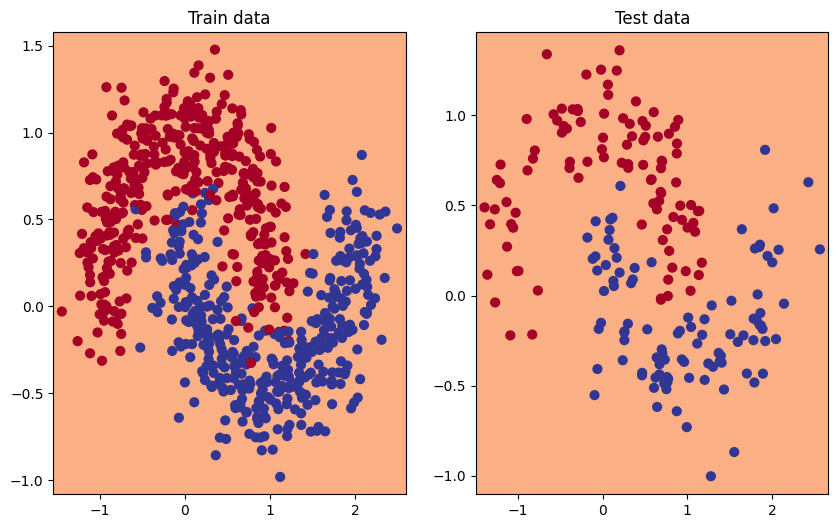

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title('Train data')
plot_decision_boundary(model_moon, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test data')
plot_decision_boundary(model_moon, X_test, y_test)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_moon.parameters(), lr=0.001)

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00


In [ ]:
from torchmetrics.classification import BinaryAccuracy
accuracy = BinaryAccuracy()

In [ ]:
  y_logits = model_moon(X_train).squeeze()
  y_preds = torch.sigmoid(y_logits)
  y_preds[:5], y_preds.shape

(tensor([0.5422, 0.5190, 0.5257, 0.5261, 0.5338], grad_fn=<SliceBackward0>),
 torch.Size([800]))

In [ ]:
epochs = 1000
for epoch in range(epochs):
  model_moon.train()
  y_logits = model_moon(X_train).squeeze()
  y_preds = torch.sigmoid(y_logits)
  loss = loss_fn(y_logits, y_train)
  train_acc = accuracy(y_preds, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_moon.eval()
  test_logits = model_moon(X_test).squeeze()
  test_preds = torch.sigmoid(test_logits)
  test_loss = loss_fn(test_logits, y_test)
  test_acc = accuracy(test_preds, y_test)

  with torch.inference_mode():
    if epoch % 100 == 0:
      print(f'Epoch: {epoch} | train loss: {loss} | train acc: {train_acc} | test loss : {test_loss} | test acc: {test_acc}')

Epoch: 0 | train loss: 0.6866137981414795 | train acc: 0.5 | test loss : 0.6870362162590027 | test acc: 0.5
Epoch: 100 | train loss: 0.5853059887886047 | train acc: 0.800000011920929 | test loss : 0.594937264919281 | test acc: 0.7549999952316284
Epoch: 200 | train loss: 0.4190434217453003 | train acc: 0.8087499737739563 | test loss : 0.4450395107269287 | test acc: 0.7599999904632568
Epoch: 300 | train loss: 0.3266274333000183 | train acc: 0.8512499928474426 | test loss : 0.34167367219924927 | test acc: 0.8299999833106995
Epoch: 400 | train loss: 0.2667958438396454 | train acc: 0.8824999928474426 | test loss : 0.2693658769130707 | test acc: 0.8799999952316284
Epoch: 500 | train loss: 0.22241631150245667 | train acc: 0.9049999713897705 | test loss : 0.21750496327877045 | test acc: 0.9150000214576721
Epoch: 600 | train loss: 0.18408074975013733 | train acc: 0.9237499833106995 | test loss : 0.17425529658794403 | test acc: 0.925000011920929
Epoch: 700 | train loss: 0.15261514484882355 | tra

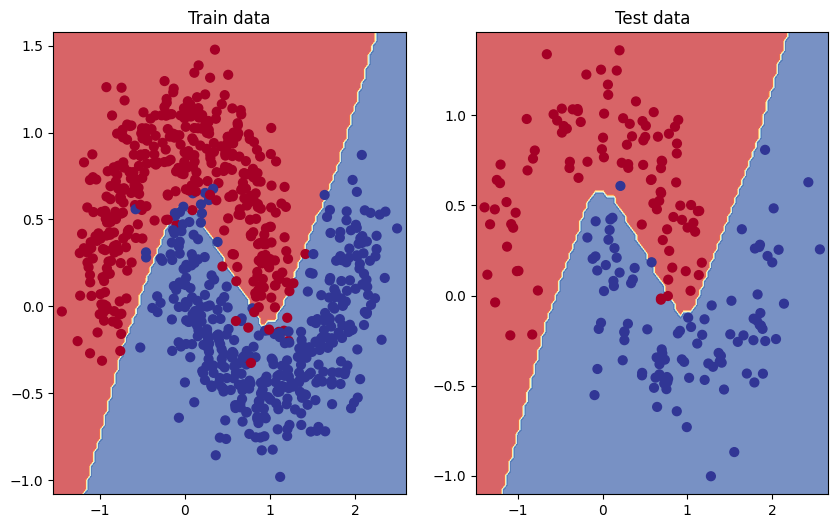

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title('Train data')
plot_decision_boundary(model_moon, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test data')
plot_decision_boundary(model_moon, X_test, y_test)

# Tanh activation function from scratch using pytorch

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
def tanh(z):
  return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

In [ ]:
z = torch.arange(-10,10, 1)
z

tensor([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9])

In [ ]:
a = tanh(z)

/tmp/ipykernel_577/4293944468.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))


In [ ]:
a

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999, -0.9993, -0.9951,
        -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,  0.9951,  0.9993,  0.9999,
         1.0000,  1.0000,  1.0000,  1.0000], dtype=torch.float64)

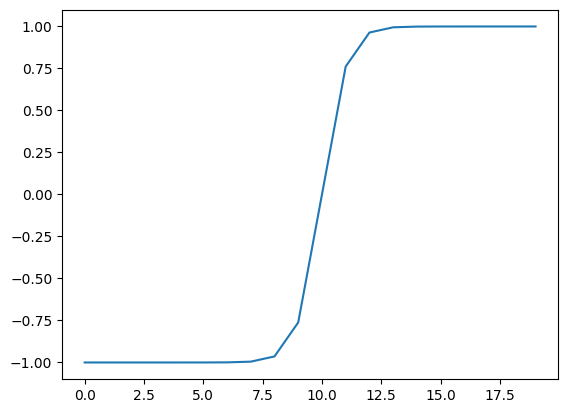

In [ ]:
plt.plot(a)

# Multi class data Assignment

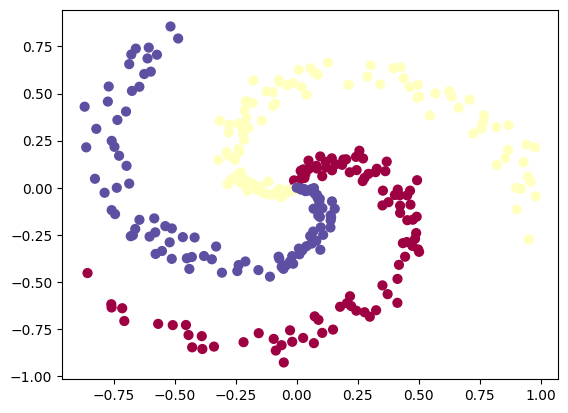

In [ ]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
len(X), len(y)

(300, 300)

In [ ]:
X[:5], y[:5]

(array([[ 0.        ,  0.        ],
        [ 0.00055659,  0.01008566],
        [ 0.00257073,  0.02003779],
        [-0.00710193,  0.02945906],
        [-0.01112669,  0.03884177]]),
 array([0, 0, 0, 0, 0], dtype=uint8))

In [ ]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [ ]:
X.dtype, y.dtype

(dtype('float64'), dtype('uint8'))

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.long)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
class Spirals(nn.Module):
  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Linear(2, 10),
        nn.ReLU(),
        nn.Linear(10, 10),
        nn.ReLU(),
        nn.Linear(10, 3)
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
spiral_model = Spirals()
spiral_model

Spirals(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=spiral_model.parameters(), lr=0.01)

In [ ]:
from torchmetrics.functional.classification import multiclass_accuracy

In [ ]:
X_train[:5]

tensor([[ 0.0089, -0.3231],
        [ 0.4977, -0.3277],
        [ 0.0315,  0.0518],
        [ 0.7680,  0.3838],
        [ 0.4956,  0.5459]])

In [ ]:
y_train.unique()

tensor([0, 1, 2])

In [ ]:
  y_logits = spiral_model(X_train).squeeze()
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)
  # train_acc = accuracy(y_preds, y_train)
  y_preds[:5]


tensor([0, 0, 0, 0, 0])

In [ ]:
epochs = 100
for epoch in range(epochs):
  spiral_model.train()
  y_logits = spiral_model(X_train).squeeze()
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)
  train_acc = multiclass_accuracy(y_preds, y_train, num_classes=3, average='micro')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  spiral_model.eval()
  test_logits = spiral_model(X_test).squeeze()
  test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
  test_loss = loss_fn(test_logits, y_test)
  test_acc = multiclass_accuracy(test_preds, y_test, num_classes=3, average='micro')

  with torch.inference_mode():
    if epoch % 10 == 0:
      print(f'Epoch: {epoch} | train loss: {loss} | train acc: {train_acc} | test loss : {test_loss} | test acc: {test_acc}')


Epoch: 0 | train loss: 0.016309041529893875 | train acc: 0.9916666746139526 | test loss : 0.0001518344070063904 | test acc: 1.0
Epoch: 10 | train loss: 0.016253657639026642 | train acc: 0.9916666746139526 | test loss : 0.00015258403436746448 | test acc: 1.0
Epoch: 20 | train loss: 0.016202254220843315 | train acc: 0.9916666746139526 | test loss : 0.0001588937157066539 | test acc: 1.0
Epoch: 30 | train loss: 0.016151783987879753 | train acc: 0.9916666746139526 | test loss : 0.0001626033044885844 | test acc: 1.0
Epoch: 40 | train loss: 0.016103411093354225 | train acc: 0.9916666746139526 | test loss : 0.00016450232942588627 | test acc: 1.0
Epoch: 50 | train loss: 0.01605512946844101 | train acc: 0.9916666746139526 | test loss : 0.00016263430006802082 | test acc: 1.0
Epoch: 60 | train loss: 0.016005046665668488 | train acc: 0.9916666746139526 | test loss : 0.00016335082182195038 | test acc: 1.0
Epoch: 70 | train loss: 0.01595570147037506 | train acc: 0.9916666746139526 | test loss : 0.000

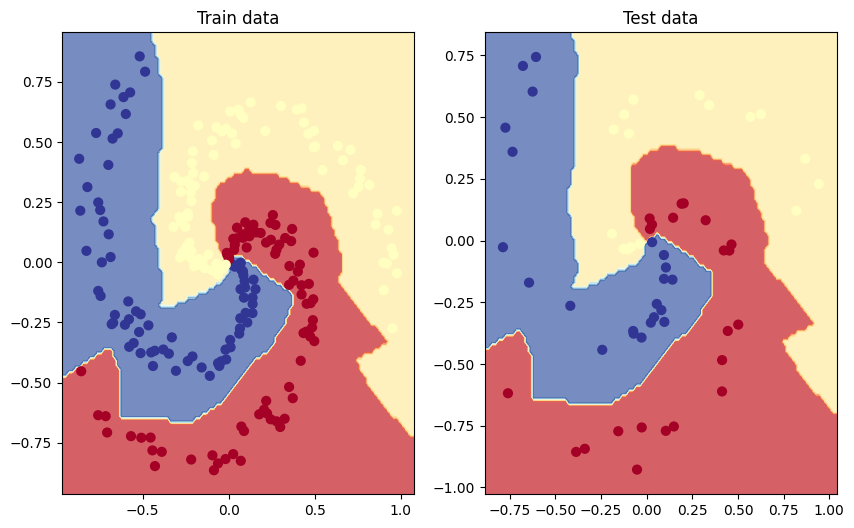

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title('Train data')
plot_decision_boundary(spiral_model, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test data')
plot_decision_boundary(spiral_model, X_test, y_test)